<a href="https://colab.research.google.com/github/KevvCh/credit-risk-analysis-app/blob/main/Credit_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()  # Upload credit_risk_dataset.csv

### Running a Streamlit App in Colab

To run a Streamlit app in Colab and access it, you need to:

1.  **Install necessary libraries**: `streamlit` and `pyngrok`.
2.  **Create your Streamlit app file**: Use `%%writefile` magic command to save your Streamlit code into a file (e.g., `app.py`).
3.  **Run the Streamlit app**: Execute `streamlit run app.py` in the background.
4.  **Expose the app**: Use `ngrok` to create a public URL for your Streamlit app.

Let's start by installing the libraries:

In [6]:
# Install streamlit and pyngrok
!pip install -q streamlit pyngrok

Now, let's create a simple `app.py` file with some Streamlit code using the `%%writefile` magic command. This will save the content below into a file named `app.py` in your current Colab working directory.

In [7]:
%%writefile app.py

import streamlit as st

st.set_page_config(layout='wide')
st.title('Colab Streamlit App Example')
st.write('This is a simple Streamlit app running in Google Colab!')

name = st.text_input('Enter your name:')
if name:
    st.write(f'Hello, {name}!')

value = st.slider('Select a value', 0, 100, 50)
st.write(f'Selected value: {value}')

Overwriting app.py


Finally, we will run the `app.py` file using `streamlit run` and then use `pyngrok` to get a public URL. Please note that for `ngrok` to work reliably and avoid rate limits, you might need to sign up for an `ngrok` account and add your authentication token. For this example, it might work without it, but if you encounter issues, consider getting an `ngrok` token from [ngrok.com](https://ngrok.com/signup) and setting it up (e.g., `ngrok.set_auth_token('YOUR_AUTH_TOKEN')`).

In [ ]:
from pyngrok import ngrok
import subprocess
import time

# --- IMPORTANT: Set your ngrok authentication token here ---
# 1. Sign up for a free ngrok account: https://dashboard.ngrok.com/signup
# 2. Get your Auth Token: https://dashboard.ngrok.com/get-started/your-authtoken
# 3. Replace 'YOUR_AUTH_TOKEN' with your actual token.
ngrok.set_auth_token('YOUR_AUTH_TOKEN') # Uncomment this line and paste your token


# Kill any processes running on port 8501 (Streamlit's default port)
!kill -9 $(lsof -i:8501 -t) 2>/dev/null

# Run Streamlit app in the background
print('Starting Streamlit app...')
process = subprocess.Popen(['streamlit', 'run', 'app.py'], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# Wait a moment for Streamlit to start
time.sleep(5)

# Connect ngrok to the Streamlit port
try:
    # Close any existing ngrok tunnels
    ngrok.kill()

    # Establish a new tunnel
    public_url = ngrok.connect(port='8501', bind_tls=True)
    print(f'\nYour Streamlit app is live at: {public_url}')
    print('Click the link above to view your app.')
    print('To stop the Streamlit app and ngrok tunnel, interrupt this cell (Runtime -> Interrupt execution).')

except Exception as e:
    print(f"Error connecting ngrok: {e}")
    print("\nIt looks like ngrok authentication failed or there was another connection issue.")
    print("Please ensure you have set your ngrok auth token by uncommenting and updating the line: `ngrok.set_auth_token('YOUR_AUTH_TOKEN')` at the top of this cell.")
    print("You can get your token from: https://dashboard.ngrok.com/get-started/your-authtoken")

# To keep the Streamlit app alive, this cell needs to keep running.
# Interrupt execution (Runtime -> Interrupt execution) to stop it.

In [9]:
import pandas as pd
import zipfile
import os

# Assuming 'archive(1).zip' contains 'credit_risk_dataset.csv'
# If the zip file name or content is different, please adjust accordingly.
zip_file_path = 'archive(1).zip'
extract_dir = '.' # Extract to current directory

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Now read the CSV file that was extracted
data = pd.read_csv("credit_risk_dataset.csv")
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Data Cleaning


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = data.drop("loan_status", axis=1)  # Features
y = data["loan_status"]               # Target (0 = default, 1 = non-default)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Exploratory Data Analysis EDA


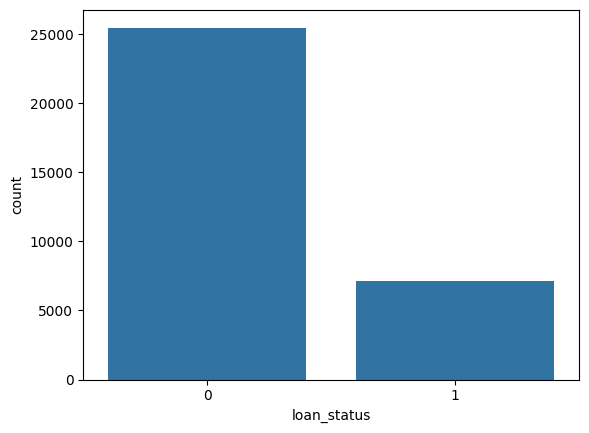

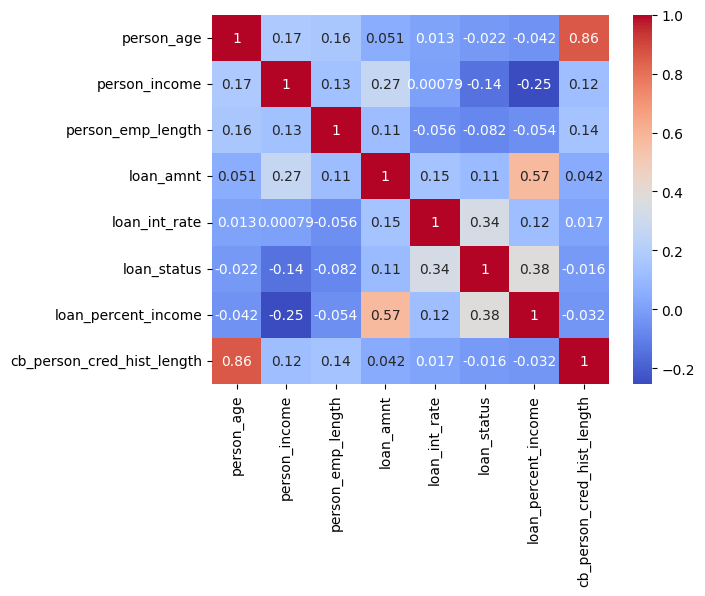

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="loan_status", data=data)
plt.show()

sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

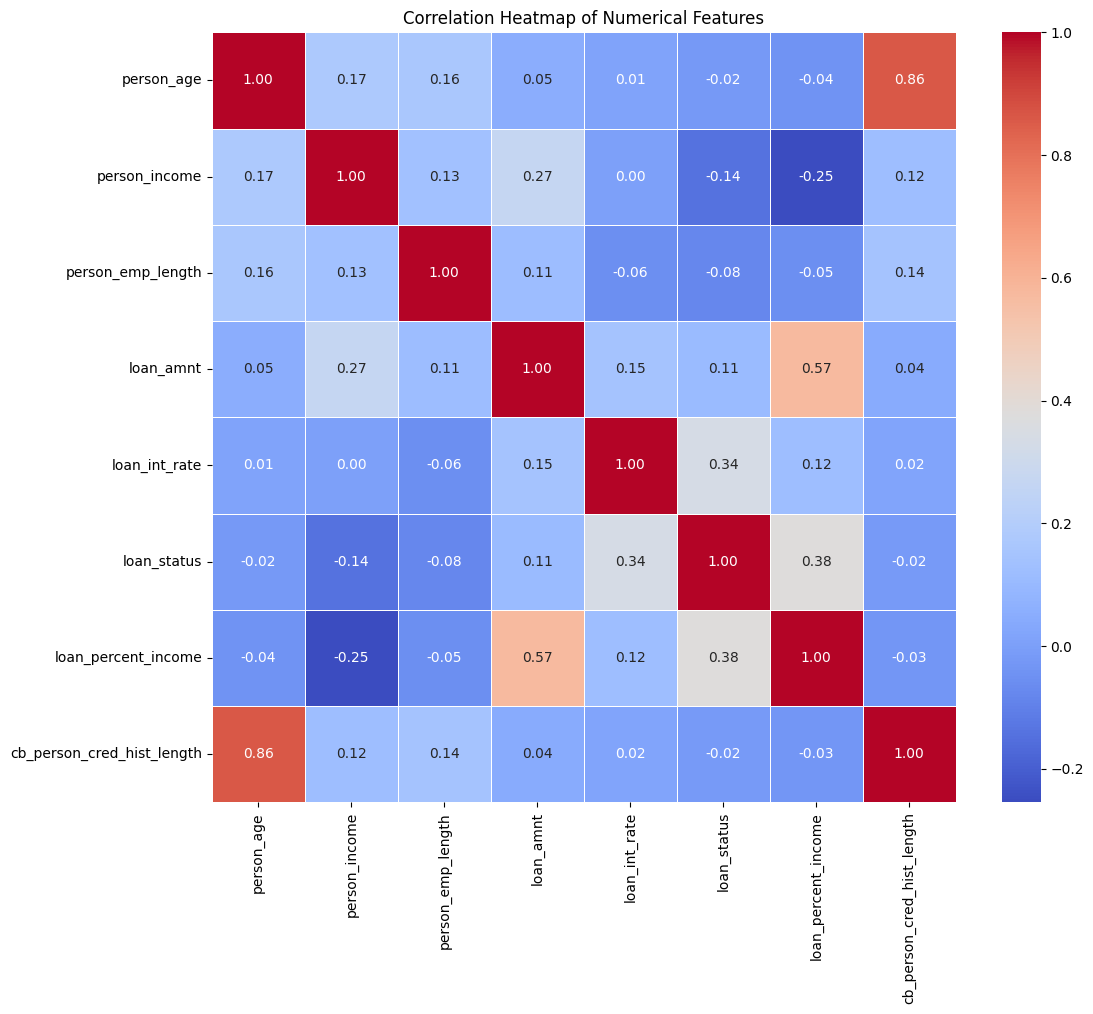

In [12]:
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Feature engineering

In [13]:
data["DebtIncomeRatio"] = data["loan_amnt"] / data["person_income"]

### Additional Feature Engineering

Let's create a few more features to potentially improve model performance. These include:

1.  **Employment History Length (Categorical):** Categorizing employment length into bins to capture non-linear relationships.
2.  **Loan Interest Rate Level:** Categorizing loan interest rates into low, medium, and high for clearer interpretation.
3.  **Monthly Loan Payment:** Estimating a monthly loan payment based on loan amount and interest rate.
4.  **Income Stability (Hypothetical):** A hypothetical feature combining employment length and income to infer stability.

In [14]:
# 1. Employment History Length (Categorical)
# Define bins for employment length (e.g., 0-2 years, 3-5 years, 6-10 years, >10 years)
bins_emp_length = [-1, 2, 5, 10, data['person_emp_length'].max() + 1]
labels_emp_length = ['0-2 Years', '3-5 Years', '6-10 Years', '10+ Years']
data['EmpLengthCategory'] = pd.cut(data['person_emp_length'], bins=bins_emp_length, labels=labels_emp_length, right=False)

# Display the new feature
display(data[['person_emp_length', 'EmpLengthCategory']].head())

,person_emp_length,EmpLengthCategory
0,123.0,10+ Years
1,5.0,6-10 Years
2,1.0,0-2 Years
3,4.0,3-5 Years
4,8.0,6-10 Years


In [15]:
# 2. Loan Interest Rate Level
# Define bins for loan interest rate
bins_int_rate = [data['loan_int_rate'].min() -1, 7, 12, data['loan_int_rate'].max() + 1]
labels_int_rate = ['Low', 'Medium', 'High']
data['InterestRateLevel'] = pd.cut(data['loan_int_rate'], bins=bins_int_rate, labels=labels_int_rate, right=False)

# Display the new feature
display(data[['loan_int_rate', 'InterestRateLevel']].head())

,loan_int_rate,InterestRateLevel
0,16.02,High
1,11.14,Medium
2,12.87,High
3,15.23,High
4,14.27,High


In [16]:
# 3. Monthly Loan Payment (Simplified Calculation)
# This is a simplified calculation, a real EMI calculation is more complex.
# Assuming a fixed loan term (e.g., 5 years = 60 months) for simplicity
loan_term_months = 60
data['MonthlyLoanPayment'] = data['loan_amnt'] / loan_term_months

# Display the new feature
display(data[['loan_amnt', 'MonthlyLoanPayment']].head())

,loan_amnt,MonthlyLoanPayment
0,35000,583.333333
1,1000,16.666667
2,5500,91.666667
3,35000,583.333333
4,35000,583.333333


In [17]:
# 4. Income Stability (Hypothetical - combination of emp_length and income)
# Higher employment length and income generally mean more stability
data['IncomeStability'] = data['person_emp_length'] * data['person_income']

# Display the new feature
display(data[['person_emp_length', 'person_income', 'IncomeStability']].head())

,person_emp_length,person_income,IncomeStability
0,123.0,59000,7257000.0
1,5.0,9600,48000.0
2,1.0,9600,9600.0
3,4.0,65500,262000.0
4,8.0,54400,435200.0


In [18]:
# Check for missing values in the updated dataset
missing_values = data.isnull().sum()
display(missing_values[missing_values > 0])

,0
person_emp_length,895
loan_int_rate,3116
EmpLengthCategory,895
InterestRateLevel,3116
IncomeStability,895


### Imputing Missing Values

Based on the missing value check, `person_emp_length` and `loan_int_rate` have missing values. We will impute these using the mean of each column. For the categorical features derived from these, the `pd.cut` function will automatically handle NaNs by placing them in a `NaN` category, which `OneHotEncoder` can handle.

In [19]:
# Impute missing values in 'person_emp_length' with the mean
data['person_emp_length'].fillna(data['person_emp_length'].mean(), inplace=True)

# Impute missing values in 'loan_int_rate' with the mean
data['loan_int_rate'].fillna(data['loan_int_rate'].mean(), inplace=True)

# Re-create derived features that might have NaNs due to initial missing values
# This ensures consistency after imputation of parent columns.

# 1. Employment History Length (Categorical) - Re-run after imputing person_emp_length
bins_emp_length = [-1, 2, 5, 10, data['person_emp_length'].max() + 1]
labels_emp_length = ['0-2 Years', '3-5 Years', '6-10 Years', '10+ Years']
data['EmpLengthCategory'] = pd.cut(data['person_emp_length'], bins=bins_emp_length, labels=labels_emp_length, right=False)

# 2. Loan Interest Rate Level - Re-run after imputing loan_int_rate
bins_int_rate = [data['loan_int_rate'].min() -1, 7, 12, data['loan_int_rate'].max() + 1]
labels_int_rate = ['Low', 'Medium', 'High']
data['InterestRateLevel'] = pd.cut(data['loan_int_rate'], bins=bins_int_rate, labels=labels_int_rate, right=False)

# 4. Income Stability (Hypothetical) - Re-run after imputing person_emp_length
data['IncomeStability'] = data['person_emp_length'] * data['person_income']


print("Missing values after imputation:")
display(data[['person_emp_length', 'loan_int_rate', 'EmpLengthCategory', 'InterestRateLevel', 'IncomeStability']].isnull().sum())

Missing values after imputation:


/tmp/ipykernel_470/290397775.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['person_emp_length'].fillna(data['person_emp_length'].mean(), inplace=True)
/tmp/ipykernel_470/290397775.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

,0
person_emp_length,0
loan_int_rate,0
EmpLengthCategory,0
InterestRateLevel,0
IncomeStability,0


### Summary Statistics for Updated Dataset

Let's review the descriptive statistics for the numerical and categorical features in the dataset after all the previous steps (loading, initial cleaning, feature engineering, and missing value imputation).

In [20]:
# Display summary statistics for numerical features
print("\nSummary Statistics for Numerical Features:")
display(data.describe())


Summary Statistics for Numerical Features:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,DebtIncomeRatio,MonthlyLoanPayment,IncomeStability
count,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,3.258100e+04
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211,0.170553,159.822852,3.502463e+05
std,6.348078,6.198312e+04,4.085333,6322.086646,3.081605,0.413006,0.106782,4.055001,0.107049,105.368111,6.778530e+05
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,0.000789,8.333333,0.000000e+00
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000,0.089655,83.333333,7.920000e+04
50%,26.000000,5.500000e+04,4.000000,8000.000000,11.011695,0.000000,0.150000,4.000000,0.148148,133.333333,2.100000e+05
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000,0.229167,203.333333,4.400000e+05
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000,0.830000,583.333333,7.200000e+07


In [21]:
# Display summary statistics for categorical features
print("\nSummary Statistics for Categorical Features:")
display(data.describe(include='object'))


Summary Statistics for Categorical Features:


,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


Model Building

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer # Import SimpleImputer

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object', 'bool']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Create a preprocessor using ColumnTransformer with imputation
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')), # Impute numerical missing values
            ('scaler', StandardScaler())
        ]), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# Train models using pipelines for preprocessing and model fitting
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', model)])
    pipeline.fit(X_train, y_train)
    models[name] = pipeline # Store the trained pipeline

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:06:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model Evaluation


In [23]:
from sklearn.metrics import classification_report, roc_auc_score

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))


Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      5072
           1       0.76      0.55      0.64      1445

    accuracy                           0.86      6517
   macro avg       0.82      0.75      0.78      6517
weighted avg       0.85      0.86      0.85      6517

ROC-AUC: 0.7486107321013392

Random Forest Results:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5072
           1       0.96      0.72      0.82      1445

    accuracy                           0.93      6517
   macro avg       0.94      0.86      0.89      6517
weighted avg       0.93      0.93      0.93      6517

ROC-AUC: 0.855423493390676

XGBoost Results:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5072
           1       0.95      0.74      0.83      1445

    accuracy                           0.93      6517
 